### Generating dataset / simulations using ns3-sem

In [2]:
import sem
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
sns.set_style("whitegrid")
import random
import pandas as pd
import io
from io import StringIO


In [3]:
# This cell may take few times to build if first usage (also, change_parallel_process to 1 if you are not using gpu)
import sem
ns_path = 'ns-3-dev/'
script = 'ai-ns3'
campaign_dir = 'testResults-ai'
campaign = sem.CampaignManager.new(
    ns_path=ns_path,
    script=script,
    campaign_dir=campaign_dir,
    overwrite=True,
    max_parallel_processes=8
)


In [4]:
print(campaign)

--- Campaign info ---
script: ai-ns3
params: {'LinkDataRate': '5Mbps', 'LinkDelay': '2ms', 'AppPacketSize': 1024.0, 'MaxPackets': 10.0, 'Interval': 0.1}
HEAD: e5039092b3bb5d7942d973cc1016eaa60bdce51c
Runner type: <class 'sem.parallelrunner.ParallelRunner'>
-----------


In [5]:
#check the input of the datarates and delays
params = {
    'LinkDataRate' :["100Kbps","500Kbps","1Mbps","5Mbps","10Mbps","15Mbps"], 
    'LinkDelay'    :["2ms","10ms","50ms","100ms","200ms","500ms","1000ms"],
    'AppPacketSize' :["1000","1024","1400","1500"],
    'MaxPackets' : ["10","20","30","40","50"],
    'Interval' : [0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]


}
runs = 1 #specify how many randomized experiments we want sem to perform for each parameter combination
# put 1 to have only unique values and not duplicate in case the experiments are deterministic

campaign.run_missing_simulations(params, runs=runs) #this will run 24 experiments

Running simulations: 100%|██████████| 8400/8400 [01:30<00:00, 92.59simulation/s]


### Parsing data

Example for one experiment

In [6]:
print("There are %s results in the database\n" % len(list(campaign.db.get_complete_results())))
example_result = campaign.db.get_complete_results()[0]
print("This is an example result:\n")
pprint.pprint(example_result)

There are 8400 results in the database

This is an example result:

{'meta': {'elapsed_time': 0.10040020942687988,
          'exitcode': 0,
          'id': '3728574e-8819-4853-960c-bc5dc716c5ec'},
 'output': {'network_data.csv': 'FlowID,SourceIP,DestinationIP,SourcePort,DestinationPort,Protocol,TxPackets,RxPackets,TxBytes,RxBytes,LostPackets,TimesForwarded,DelaySum_s,JitterSum_s,TimeFirstTx_s,TimeLastTx_s,TimeFirstRx_s,TimeLastRx_s,MeanDelay(s),MeanJitter(s),MeanTxPktSize(bytes),MeanRxPktSize(bytes),txDuration(s),rxDuration(s),MeanTxBitrate(bps),MeanRxBitrate(bps),MeanHopCount,PacketLossRatio\n'
                                '1,10.1.1.1,10.1.1.2,49153,9,UDP,12,12,17136,17136,0,0,2.67456,0,2,9.7,2.22288,9.92288,0.22288,0,1428,1428,7.7,7.7,17803.6,17803.6,1,0,\n'
                                '2,10.1.1.2,10.1.1.1,9,49153,UDP,12,12,17136,17136,0,0,2.67456,0,2.22288,9.92288,2.44576,10.1458,0.22288,0,1428,1428,7.7,7.7,17803.6,17803.6,1,0,\n',
            'stderr': '',
            'stdou

ns3-sem provides a more compact way to extract data for each experiment but it works only if one needs one output whereas we need multiple outputs/features so we access instead the dictionary storing the metadata, the parameters and the outputs of each experiment. Here is an example for one single experiment

In [7]:
# Extract CSV string from output
csv_str = example_result['output']['network_data.csv']

# Load CSV string into a DataFrame
df = pd.read_csv(StringIO(csv_str), index_col=False)

# Add experiment metadata
df['experiment_id'] = example_result['meta']['id']
df['exitcode'] = example_result['meta']['exitcode'] #use to verify that the file was correctly executed (return 0)
df['elapsed_time'] = example_result['meta']['elapsed_time']

#  Add parameters columns (flatten the params dict into DataFrame columns)
for key, value in example_result['params'].items():
    df[key] = value

# Now df contains all CSV data rows plus experiment ID and parameter columns
df.head()

,FlowID,SourceIP,DestinationIP,SourcePort,DestinationPort,Protocol,TxPackets,RxPackets,TxBytes,RxBytes,...,PacketLossRatio,experiment_id,exitcode,elapsed_time,LinkDataRate,LinkDelay,AppPacketSize,MaxPackets,Interval,RngRun
0,1,10.1.1.1,10.1.1.2,49153,9,UDP,12,12,17136,17136,...,0,3728574e-8819-4853-960c-bc5dc716c5ec,0,0.1004,500Kbps,200ms,1400,40,0.7,2338
1,2,10.1.1.2,10.1.1.1,9,49153,UDP,12,12,17136,17136,...,0,3728574e-8819-4853-960c-bc5dc716c5ec,0,0.1004,500Kbps,200ms,1400,40,0.7,2338


We do the above for all the experiments and stack them in the same dataframe

In [8]:
import pandas as pd

big_df_list = []  # list to collect smaller dataframes

for example_result in campaign.db.get_complete_results():
    # Extract CSV string from output
    csv_str = example_result['output']['network_data.csv']

    #  Load CSV string into a DataFrame
    df = pd.read_csv(StringIO(csv_str), index_col=False)

    # Add experiment metadata
    df['experiment_id'] = example_result['meta']['id']
    df['exitcode'] = example_result['meta']['exitcode'] #use to verify that the file was correctly executed (return 0)
    df['elapsed_time'] = example_result['meta']['elapsed_time']

    # Step 4: Add parameters columns (flatten the params dict into DataFrame columns)
    for key, value in example_result['params'].items():
        df[key] = value

    
    big_df_list.append(df)

# After the loop, concatenate all at once
big_df = pd.concat(big_df_list, ignore_index=True)
#big_df.shape #the number of rows =sum (number of flows per experiment) e.g. is there are 2 flows for 16800 experiments, the df will have 33600 rows

In [9]:
big_df.head()

,FlowID,SourceIP,DestinationIP,SourcePort,DestinationPort,Protocol,TxPackets,RxPackets,TxBytes,RxBytes,...,PacketLossRatio,experiment_id,exitcode,elapsed_time,LinkDataRate,LinkDelay,AppPacketSize,MaxPackets,Interval,RngRun
0,1,10.1.1.1,10.1.1.2,49153,9,UDP,12,12,17136,17136,...,0,3728574e-8819-4853-960c-bc5dc716c5ec,0,0.100400,500Kbps,200ms,1400,40,0.7,2338
1,2,10.1.1.2,10.1.1.1,9,49153,UDP,12,12,17136,17136,...,0,3728574e-8819-4853-960c-bc5dc716c5ec,0,0.100400,500Kbps,200ms,1400,40,0.7,2338
2,1,10.1.1.1,10.1.1.2,49153,9,UDP,30,30,30840,30840,...,0,16a773bc-0b80-4c02-afc7-f833ff89e020,0,0.101856,5Mbps,10ms,1000,30,0.1,4422
3,2,10.1.1.2,10.1.1.1,9,49153,UDP,30,30,30840,30840,...,0,16a773bc-0b80-4c02-afc7-f833ff89e020,0,0.101856,5Mbps,10ms,1000,30,0.1,4422
4,1,10.1.1.1,10.1.1.2,49153,9,UDP,10,10,14280,14280,...,0,cebef3a4-1d6d-406d-b651-11ecf95636ae,0,0.102009,15Mbps,1000ms,1400,10,0.7,8308


In [10]:
big_df.columns

Index(['FlowID', 'SourceIP', 'DestinationIP', 'SourcePort', 'DestinationPort',
       'Protocol', 'TxPackets', 'RxPackets', 'TxBytes', 'RxBytes',
       'LostPackets', 'TimesForwarded', 'DelaySum_s', 'JitterSum_s',
       'TimeFirstTx_s', 'TimeLastTx_s', 'TimeFirstRx_s', 'TimeLastRx_s',
       'MeanDelay(s)', 'MeanJitter(s)', 'MeanTxPktSize(bytes)',
       'MeanRxPktSize(bytes)', 'txDuration(s)', 'rxDuration(s)',
       'MeanTxBitrate(bps)', 'MeanRxBitrate(bps)', 'MeanHopCount',
       'PacketLossRatio', 'experiment_id', 'exitcode', 'elapsed_time',
       'LinkDataRate', 'LinkDelay', 'AppPacketSize', 'MaxPackets', 'Interval',
       'RngRun'],
      dtype='object')

### Exploring and visualizing the data

In [11]:
big_df[['MeanDelay(s)', 'MeanJitter(s)', 'MeanTxPktSize(bytes)']].describe()

,MeanDelay(s),MeanJitter(s),MeanTxPktSize(bytes)
count,16800.000000,16800.000000,16800.000000
mean,0.308329,0.001363,1259.000000
std,0.381230,0.009891,222.004355
min,0.002549,0.000000,1028.000000
25%,0.050763,0.000000,1046.000000
50%,0.124832,0.000000,1240.000000
75%,0.501242,0.000000,1453.000000
max,3.921080,0.114160,1528.000000


In [12]:
"""
sns.histplot(data=big_df, x='MeanJitter(s)', bins=30, kde=False)
plt.xlabel('MeanJitter(s)')
plt.ylabel('Count')
plt.title('Histogram of MeanDelay(s)')
plt.show()
"""


"\nsns.histplot(data=big_df, x='MeanJitter(s)', bins=30, kde=False)\nplt.xlabel('MeanJitter(s)')\nplt.ylabel('Count')\nplt.title('Histogram of MeanDelay(s)')\nplt.show()\n"

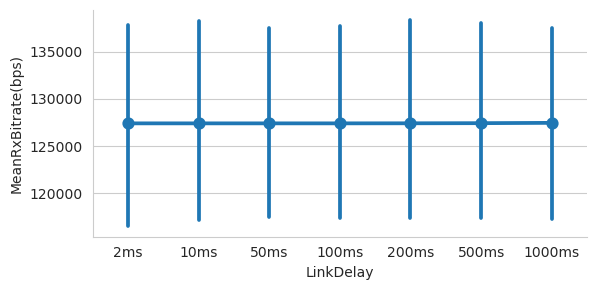

In [13]:
sns.catplot(data=big_df,
            x='LinkDelay',
            y='MeanRxBitrate(bps)',
            kind='point',
            order = params['LinkDelay'],#order=["100Kbps","500Kbps","1Mbps","5Mbps","10Mbps","15Mbps"],
            height=3,
            aspect=2)  # Width = height * aspect, so 5*2 = 10)
plt.show()

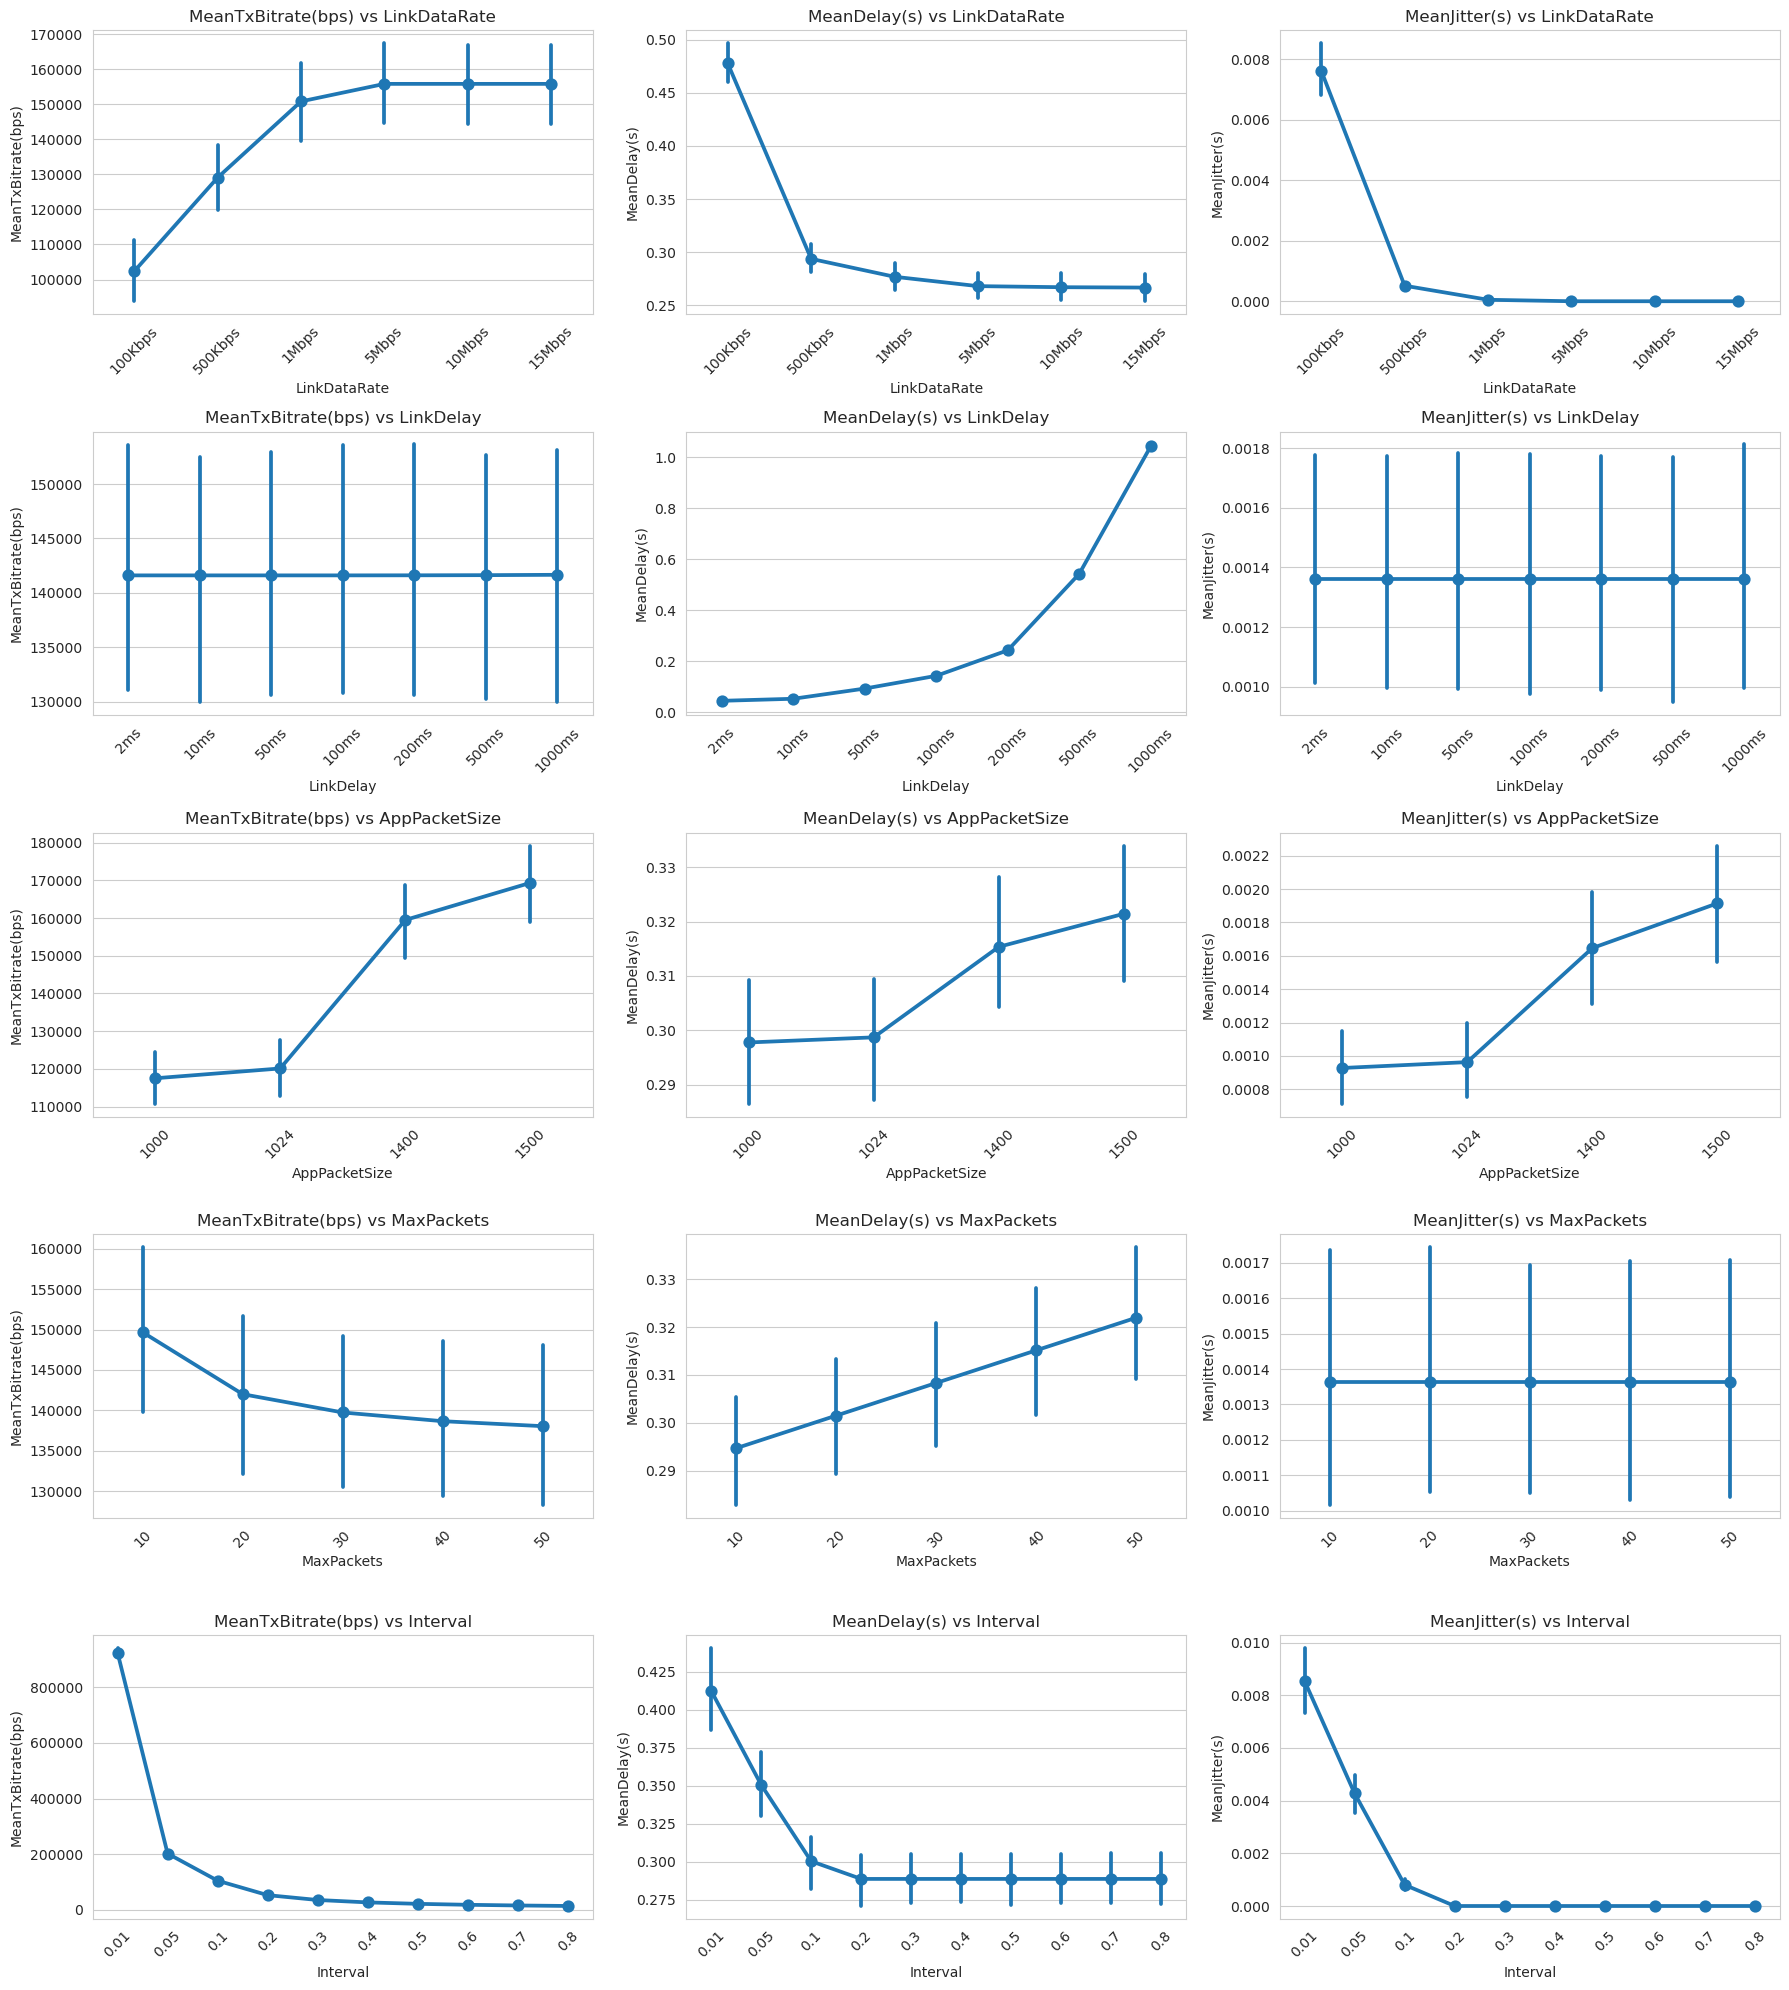

In [14]:
#decomment for visualization 
# y variables (metrics you want to plot)

cvars = ['MeanTxBitrate(bps)','MeanDelay(s)','MeanJitter(s)' ]  #  'MeanTxBitrate(bps)'

# Number of subplots = number of x_vars * number of cvars
n_rows = len(params)
n_cols = len(cvars)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)

for i, x_var in enumerate(params.keys()):
    order = params[x_var]
    for j, y_var in enumerate(cvars):
        ax = axes[i][j]

        sns.pointplot(
            data=big_df,
            x=x_var,
            y=y_var,
            order=order,
            ax=ax,
            dodge=True,
            markers='o',
            linestyles='-'
        )

        ax.set_title(f"{y_var} vs {x_var}")
        ax.set_xlabel(x_var)
        ax.set_ylabel(y_var)

        # Optional: rotate x labels if needed
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In [15]:
cvars = ['MeanTxBitrate(bps)','MeanDelay(s)','MeanJitter(s)' ]
"""
sns.boxplot(data=big_df, x='LinkDataRate', y='MeanTxBitrate(bps)', order=params['LinkDataRate'])
sns.relplot(
    data=big_df,
    x='Interval',
    y='MeanDelay(s)',
    kind='line',
    hue='LinkDataRate',
    col='LinkDelay',
    col_wrap=3
)
"""


"\nsns.boxplot(data=big_df, x='LinkDataRate', y='MeanTxBitrate(bps)', order=params['LinkDataRate'])\nsns.relplot(\n    data=big_df,\n    x='Interval',\n    y='MeanDelay(s)',\n    kind='line',\n    hue='LinkDataRate',\n    col='LinkDelay',\n    col_wrap=3\n)\n"

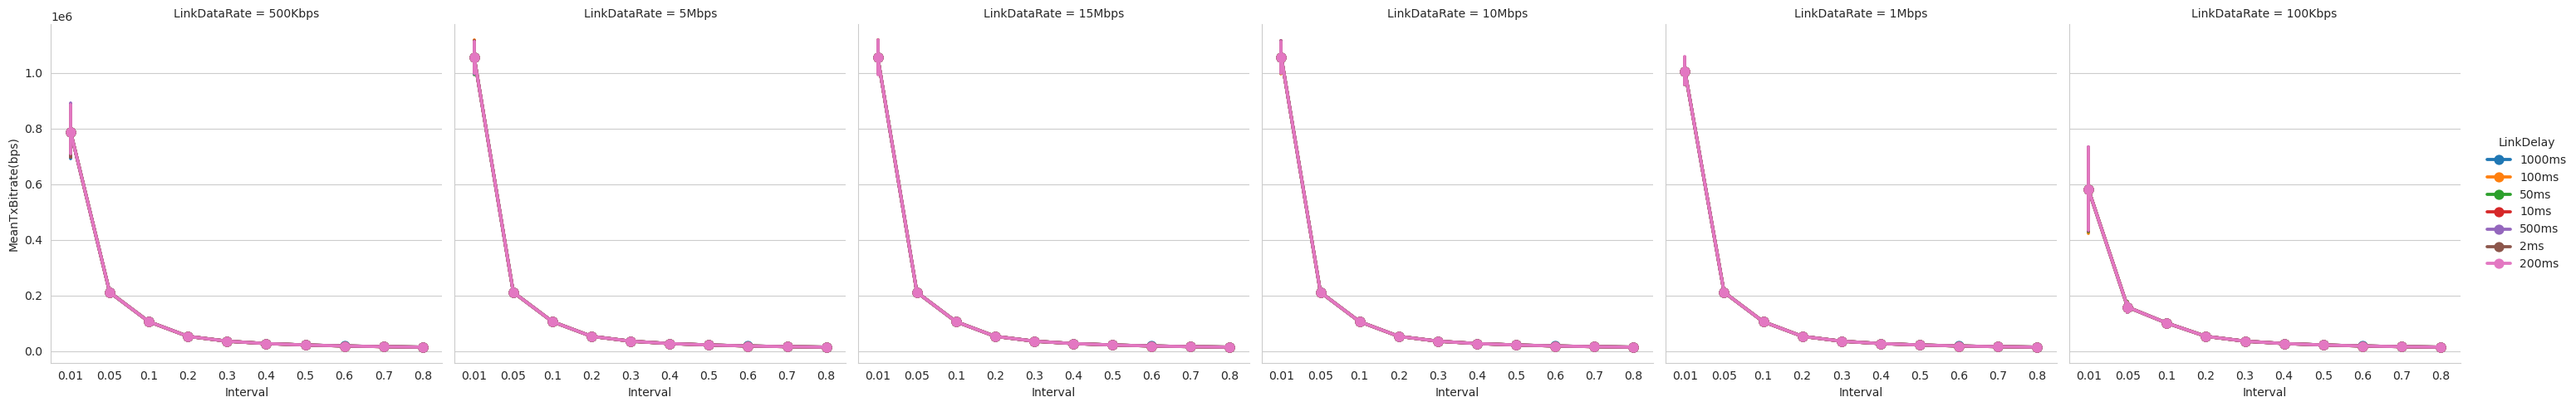

In [16]:
sns.catplot(data=big_df,
            x='Interval',
            y='MeanTxBitrate(bps)',#['MeanTxBitrate(bps)','MeanDelay(s)','MeanJitter(s)' ]
            col='LinkDataRate', 
            hue='LinkDelay',
            kind='point')
plt.show()


### Sensitivty analysis

-   The output metric is strongly influenced by combinations of parameters.
-   No single parameter dominates on its own.
-   The model is non-linear and has strong interactions.

In [17]:
import pandas as pd
from io import StringIO
from SALib.analyze import sobol

# 1. Load SEM results into a DataFrame
results = campaign.db.get_complete_results()
rows = []

for r in results:
    params = r['params']
    
    # Parse CSV string into DataFrame
    df_csv = pd.read_csv(StringIO(r['output']['network_data.csv']))
    
    # Example: take the mean of MeanTxBitrate(bps) (or another aggregation)
    metric = df_csv['MeanTxBitrate(bps)'].mean()
    
    rows.append({**params, 'output': metric})

df_sensitivity = pd.DataFrame(rows)

# 2. Define problem for SALib
#param_names = list(r['params'].keys())
param_names = list(r['params'].keys())
"""
param_bounds = [
    [df_sensitivity[p].min(), df_sensitivity[p].max()]
    for p in param_names
]
"""
param_bounds=[["100Kbps","500Kbps","1Mbps","5Mbps","10Mbps","15Mbps"],["2ms","10ms","50ms","100ms","200ms","500ms","1000ms"],
              ["1000","1024","1400","1500"],["10","20","30","40","50"],[0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]]

problem = {
    'num_vars': len(param_names),
    'names': param_names,
    'bounds': param_bounds
}

# 3. Extract X and Y
X = df_sensitivity[param_names].to_numpy()
Y = df_sensitivity['output'].to_numpy()

# 4. Sobol sensitivity analysis
Si = sobol.analyze(problem, Y, calc_second_order=False, print_to_console=True)


                     ST   ST_conf
LinkDataRate   0.923822  0.119037
LinkDelay      1.021319  0.168224
AppPacketSize  0.955203  0.151880
MaxPackets     0.954150  0.122960
Interval       0.923864  0.131411
RngRun         0.949224  0.154118
                     S1   S1_conf
LinkDataRate   0.058182  0.086634
LinkDelay     -0.016770  0.070618
AppPacketSize  0.001267  0.079382
MaxPackets     0.039240  0.085120
Interval      -0.000018  0.076772
RngRun         0.014736  0.085827


/home/nourhen/.local/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


### Training the model

In [18]:
import numpy as np

import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

It takes 5-11mins to train the model

this is the wrong pipeline that includes delay_sum and jitter_sum and dataLink... are kept categorical

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score



# 2. Separate features (X) and targets (Y)
target_cols = ['MeanTxBitrate(bps)','MeanRxBitrate(bps)','MeanDelay(s)','MeanJitter(s)' ]

X = big_df.drop(columns=target_cols)
Y = big_df[target_cols]

# 3. Identify numeric and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

# 4. Preprocessing
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 5. Define model
base_model = RandomForestRegressor(n_estimators=200, random_state=42)
model = MultiOutputRegressor(base_model)

# 6. Full pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", model)
])

# 7. Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# 8. Train
pipeline.fit(X_train, Y_train)

# 9. Predict
Y_pred = pipeline.predict(X_test)

# 10. Evaluate
for i, col in enumerate(target_cols):
    print(f"{col}: MAE={mean_absolute_error(Y_test[col], Y_pred[:, i]):.3f}, R2={r2_score(Y_test[col], Y_pred[:, i]):.3f}")


MeanTxBitrate(bps): MAE=78.270, R2=1.000
MeanRxBitrate(bps): MAE=0.596, R2=1.000
MeanDelay(s): MAE=0.001, R2=0.999
MeanJitter(s): MAE=0.000, R2=0.999


This is a better pipeline where previous pitfalls are dealt with

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

# -----------------------
# Step 1: Define target columns
# -----------------------
target_cols = ['MeanTxBitrate(bps)','MeanRxBitrate(bps)','MeanDelay(s)','MeanJitter(s)']

X = big_df.drop(columns=target_cols)  # keep original big_df intact
Y = big_df[target_cols]

# -----------------------
# Step 2: Custom transformer to convert and drop
# -----------------------
def convert_and_drop(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()  # keep original safe

    # Drop redundant columns
    df = df.drop(columns=['DelaySum_s', 'JitterSum_s'], errors="ignore")

    # Convert LinkDataRate to numeric (bps)
    def convert_data_rate(val):
        if isinstance(val, str):
            val = val.strip().lower()
            if val.endswith("kbps"):
                return float(val.replace("kbps", "")) * 1_000
            elif val.endswith("mbps"):
                return float(val.replace("mbps", "")) * 1_000_000
        return pd.to_numeric(val, errors="coerce")

    if "LinkDataRate" in df.columns:
        df["LinkDataRate"] = df["LinkDataRate"].apply(convert_data_rate)

    # Convert LinkDelay to numeric (seconds)
    def convert_delay(val):
        if isinstance(val, str):
            val = val.strip().lower()
            if val.endswith("ms"):
                return float(val.replace("ms", "")) / 1000  # ms → s
            elif val.endswith("s"):
                return float(val.replace("s", ""))
        return pd.to_numeric(val, errors="coerce")

    if "LinkDelay" in df.columns:
        df["LinkDelay"] = df["LinkDelay"].apply(convert_delay)

    # Convert AppPacketSize to int
    if "AppPacketSize" in df.columns:
        df["AppPacketSize"] = pd.to_numeric(df["AppPacketSize"], errors="coerce")

    # Convert MaxPackets to int
    if "MaxPackets" in df.columns:
        df["MaxPackets"] = pd.to_numeric(df["MaxPackets"], errors="coerce")

    return df

conversion_transformer = FunctionTransformer(convert_and_drop)

# -----------------------
# Step 3: Identify numeric and categorical features *after* transformation
# -----------------------
# We'll detect them dynamically after transformation during pipeline fitting
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))])

def make_preprocessor(X_df):
    numeric_features = X_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X_df.select_dtypes(include=["object", "category"]).columns.tolist()

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

# -----------------------
# Step 4: Build pipeline
# -----------------------
# Since feature detection needs to happen after the FunctionTransformer,
# we wrap the preprocessor in another FunctionTransformer that dynamically builds it.
from sklearn.base import BaseEstimator, TransformerMixin

class DynamicPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.column_transformer = None
    def fit(self, X, y=None):
        self.column_transformer = make_preprocessor(X)
        self.column_transformer.fit(X, y)
        return self
    def transform(self, X):
        return self.column_transformer.transform(X)
    def get_feature_names_out(self, input_features=None):
        return self.column_transformer.get_feature_names_out()

# Final model pipeline
pipeline = Pipeline(steps=[
    ("convert", conversion_transformer),         # Step 1: Drop + convert
    ("preprocessor", DynamicPreprocessor()),     # Step 2: Scale numeric, encode categorical
    ("regressor", MultiOutputRegressor(RandomForestRegressor(n_estimators=200, random_state=42)))
])

# -----------------------
# Step 5: Train/test split and run
# -----------------------
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

pipeline.fit(X_train, Y_train)
Y_pred = pipeline.predict(X_test)

# Evaluation

print("\n Model Evaluation (MAPE & R²):")
for i, col in enumerate(target_cols):
    mape = mean_absolute_percentage_error(Y_test[col], Y_pred[:, i]) * 100  # in %
    r2 = r2_score(Y_test[col], Y_pred[:, i])
    print(f"{col}: MAPE = {mape:.2f}%, R² = {r2:.3f}")

# -----------------------
# Feature Importances per target
# -----------------------
print("\n Feature Importances per target:")
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

for i, col in enumerate(target_cols):
    importances = pipeline.named_steps["regressor"].estimators_[i].feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    print(f"\nTarget: {col}")
    for idx in sorted_idx[:10]:  # top 10 features
        print(f"  {feature_names[idx]}: {importances[idx]:.4f}")



 Model Evaluation (MAPE & R²):
MeanTxBitrate(bps): MAPE = 0.10%, R² = 1.000
MeanRxBitrate(bps): MAPE = 0.00%, R² = 1.000
MeanDelay(s): MAPE = 1.02%, R² = 0.984
MeanJitter(s): MAPE = 15629377929676.88%, R² = 0.989

 Feature Importances per target:

Target: MeanTxBitrate(bps)
  num__Interval: 0.8679
  num__txDuration(s): 0.0770
  num__MeanRxPktSize(bytes): 0.0118
  num__MeanTxPktSize(bytes): 0.0109
  num__AppPacketSize: 0.0101
  num__RngRun: 0.0077
  num__LinkDataRate: 0.0075
  num__TimeFirstTx_s: 0.0031
  cat__SourceIP_10.1.1.2: 0.0004
  num__TimeLastTx_s: 0.0003

Target: MeanRxBitrate(bps)
  num__rxDuration(s): 0.7647
  num__Interval: 0.1577
  num__LinkDataRate: 0.0252
  num__RngRun: 0.0236
  num__MeanTxPktSize(bytes): 0.0098
  num__MeanRxPktSize(bytes): 0.0091
  num__AppPacketSize: 0.0088
  num__TxBytes: 0.0003
  num__RxBytes: 0.0002
  num__TxPackets: 0.0002

Target: MeanDelay(s)
  num__LinkDelay: 0.7782
  num__TimeLastRx_s: 0.0492
  num__TimeLastTx_s: 0.0339
  num__TimeFirstRx_s: 0.

Good pipeline usage

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
# ----------------------
# Candidate models
# ----------------------
models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "LinearRegression": LinearRegression()
}

# ----------------------
# Evaluate models
# ----------------------
results = []
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

for name, model in models.items():
    # Final model pipeline
    pipeline2 = Pipeline(steps=[
        ("convert", conversion_transformer),         # Step 1: Drop + convert
        ("preprocessor", DynamicPreprocessor()),     # Step 2: Scale numeric, encode categorical
        ("regressor", MultiOutputRegressor(model))
    ])

    
    pipeline2.fit(X_train, Y_train)
    Y_pred = pipeline2.predict(X_test)
    
    mae_scores = []
    r2_scores = []
    for i, col in enumerate(target_cols):
        mae = mean_absolute_error(Y_test[col], Y_pred[:, i])
        r2 = r2_score(Y_test[col], Y_pred[:, i])
        mae_scores.append(mae)
        r2_scores.append(r2)
    
    avg_mae = np.mean(mae_scores)
    avg_r2 = np.mean(r2_scores)
    
    results.append({
        "Model": name,
        "Avg MAE": avg_mae,
        "Avg R2": avg_r2
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print("\nBaseline model comparison:")
print(results_df.sort_values(by="Avg MAE"))



Baseline model comparison:
              Model       Avg MAE    Avg R2
0      RandomForest     79.989264  0.993263
1  GradientBoosting   2275.970243  0.976920
2  LinearRegression  20070.916863  0.815086


Bad pipeline usage and misleading errors

In [24]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score




# ----------------------
# Candidate models
# ----------------------
models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "LinearRegression": LinearRegression()
}

# ----------------------
# Evaluate models
# ----------------------
results = []
feature_importances = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", MultiOutputRegressor(model))
    ])
    
    pipeline.fit(X_train, Y_train)
    Y_pred = pipeline.predict(X_test)
    
    mae_scores = []
    r2_scores = []
    for i, col in enumerate(target_cols):
        mae = mean_absolute_error(Y_test[col], Y_pred[:, i])
        r2 = r2_score(Y_test[col], Y_pred[:, i])
        mae_scores.append(mae)
        r2_scores.append(r2)
    
    avg_mae = np.mean(mae_scores)
    avg_r2 = np.mean(r2_scores)
    
    results.append({"Model": name, "Avg MAE": avg_mae, "Avg R2": avg_r2})
    
    # Store feature importances for tree-based models
    if hasattr(model, "feature_importances_") or "RandomForest" in name or "GradientBoosting" in name:
        feature_names = (
            list(numeric_features) +
            list(pipeline.named_steps["preprocessor"].transformers_[1][1]
                 .named_steps["encoder"].get_feature_names_out(categorical_features))
        )
        importances_per_target = {}
        for i, est in enumerate(pipeline.named_steps["regressor"].estimators_):
            if hasattr(est, "feature_importances_"):
                importances = est.feature_importances_
                sorted_idx = np.argsort(importances)[::-1]
                importances_per_target[target_cols[i]] = [
                    (feature_names[idx], importances[idx]) for idx in sorted_idx[:10]
                ]
        feature_importances[name] = importances_per_target

# ----------------------
# Results table
# ----------------------
results_df = pd.DataFrame(results)
print("\nBaseline model comparison:")
print(results_df.sort_values(by="Avg MAE"))





Baseline model comparison:
              Model       Avg MAE    Avg R2
0      RandomForest     17.753219  0.999524
1  GradientBoosting   2263.304977  0.998342
2  LinearRegression  20249.280615  0.823940


### Data ablation

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from copy import deepcopy

# ---------- CONFIG ----------
target_cols = ['MeanTxBitrate(bps)','MeanRxBitrate(bps)','MeanDelay(s)','MeanJitter(s)']
X = big_df.drop(columns=target_cols)
Y = big_df[target_cols]

# Reuse your existing preprocessor (ColumnTransformer)
# preprocessor = ...
# Choose base model you want to evaluate during ablation
base_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# ---------- EVALUATION FUNCTION ----------
def evaluate_features(features, X_df, Y_df, preprocessor, model, n_splits=5, random_state=42):
    """
    Evaluate a set of original (unencoded) features using KFold CV.
    Returns mean and std of average MAE across the multioutput targets.
    """
    if len(features) == 0:
        raise ValueError("No features provided for evaluation.")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    maes = []

    for train_idx, val_idx in kf.split(X_df):
        X_train = X_df.iloc[train_idx][features]
        X_val   = X_df.iloc[val_idx][features]
        Y_train = Y_df.iloc[train_idx]
        Y_val   = Y_df.iloc[val_idx]

        # Build pipeline on the fly using the *same* preprocessor structure but restricted to `features`.
        # Easiest approach: build a new ColumnTransformer that references the numeric/categorical columns among `features`.
        # But here we reuse the given preprocessor by creating a shallow copy and adjusting columns via selection on X.
        pipeline2 = Pipeline(steps=[
            ("convert", conversion_transformer),         # Step 1: Drop + convert
            ("preprocessor", DynamicPreprocessor()),     # Step 2: Scale numeric, encode categorical
            ("regressor", MultiOutputRegressor(model))
        ])

        pipeline2.fit(X_train, Y_train)
        Y_pred = pipeline2.predict(X_val)

        # avg MAE across targets
        per_target_mae = [mean_absolute_error(Y_val.iloc[:, i], Y_pred[:, i]) for i in range(Y_val.shape[1])]
        maes.append(np.mean(per_target_mae))

    return np.mean(maes), np.std(maes)

# ---------- 1) Baseline with all features ----------
all_features = X.columns.tolist()
baseline_mean_mae, baseline_std_mae = evaluate_features(all_features, X, Y, preprocessor, base_model)
print(f"BASELINE (all features): Avg MAE = {baseline_mean_mae:.4f} ± {baseline_std_mae:.4f}")

# ---------- 2) Leave-one-feature-out (LOFO) ----------
lofo_results = []
for feat in all_features:
    features_subset = [f for f in all_features if f != feat]
    mean_mae, std_mae = evaluate_features(features_subset, X, Y, preprocessor, base_model)
    # compute delta (how much MAE increases when feature is removed). Positive = feature helpful.
    delta = mean_mae - baseline_mean_mae
    lofo_results.append({"feature": feat, "mean_mae": mean_mae, "std_mae": std_mae, "delta_mae": delta})

lofo_df = pd.DataFrame(lofo_results).sort_values("delta_mae", ascending=False)
print("\nTop features by LOFO delta (higher delta => removing it hurts more):")
print(lofo_df.head(10))

# Plot LOFO deltas
plt.figure(figsize=(10,6))
plt.barh(lofo_df['feature'], lofo_df['delta_mae'])
plt.xlabel("Delta Avg MAE (removed - baseline). Positive => feature helpful")
plt.title("Leave-One-Feature-Out (LOFO) - impact on Avg MAE")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ---------- 3) Group ablation example ----------
# Define groups (example: all categorical features vs all numeric features)
numeric_feats = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_feats = X.select_dtypes(include=["object","category"]).columns.tolist()

groups = {
    "all_features": all_features,
    "no_numeric": [f for f in all_features if f not in numeric_feats],
    "no_categorical": [f for f in all_features if f not in categorical_feats],
}

group_results = []
for gname, feats in groups.items():
    mean_mae, std_mae = evaluate_features(feats, X, Y, preprocessor, base_model)
    group_results.append({"group": gname, "mean_mae": mean_mae, "std_mae": std_mae, "delta_mae": mean_mae - baseline_mean_mae})

print("\nGroup ablation results:")
print(pd.DataFrame(group_results))

# ---------- 4) Cumulative addition following importance ranking ----------
# To get a ranking, train one RF on full data (single fit) and extract per-original-feature importance
# Note: RF works on transformed features; to get a per-original-feature importance we average importance of encoded columns that came from same original categorical column.
from sklearn.pipeline import make_pipeline

rf_for_ranking = make_pipeline(preprocessor, MultiOutputRegressor(RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)))
rf_for_ranking.fit(X, Y)

# Extract feature names after preprocessing
# For numeric: names are the same; for categorical: use encoder.get_feature_names_out
num_names = numeric_feats
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_names = list(cat_encoder.get_feature_names_out(categorical_feats)) if categorical_feats else []
transformed_feature_names = num_names + cat_names

# Collect importance per transformed feature by averaging across the estimators' importances
# final estimator is MultiOutputRegressor -> estimators_ is list of estimators per target
estimators = rf_for_ranking.named_steps['multioutputregressor'].estimators_  # may vary depending on sklearn version
# some sklearn versions wrap differently; fallback:
if estimators is None:
    estimators = rf_for_ranking.named_steps['multioutputregressor'].estimators_

importances_per_transformed = np.mean([est.feature_importances_ for est in estimators], axis=0)
# Map transformed importances back to original feature by summing encoded columns for same original categorical feature
orig_importance = {f:0.0 for f in all_features}
# numeric first
for i, n in enumerate(num_names):
    orig_importance[n] += importances_per_transformed[i]
# categorical block
offset = len(num_names)
for j, orig_cat in enumerate(categorical_feats):
    # count how many encoded columns this cat produced
    enc_names = [name for name in cat_names if name.startswith(orig_cat + "_")]
    for k, enc in enumerate(enc_names):
        idx = offset + cat_names.index(enc)
        orig_importance[orig_cat] += importances_per_transformed[idx]

# create ranking
ranked = sorted(orig_importance.items(), key=lambda x: x[1], reverse=True)
ranked_names = [r[0] for r in ranked]

# Now cumulative addition
cum_results = []
current_set = []
for feat in ranked_names:
    current_set.append(feat)
    mean_mae, std_mae = evaluate_features(current_set, X, Y, preprocessor, base_model)
    cum_results.append({"n_features": len(current_set), "last_added": feat, "mean_mae": mean_mae, "std_mae": std_mae})

cum_df = pd.DataFrame(cum_results)
print("\nCumulative addition (first 10 steps):")
print(cum_df.head(10))

plt.figure(figsize=(8,5))
plt.plot(cum_df['n_features'], cum_df['mean_mae'], marker='o')
plt.xlabel("Number of features (cumulative by importance)")
plt.ylabel("Avg MAE")
plt.title("Cumulative-addition learning curve (by feature importance)")
plt.grid(True)
plt.tight_layout()
plt.show()
